In this notebook we extract the 3d features from the untrained and the trained model. 

In [1]:
import torch
from data_utils.ABODataLoader import ABODataLoader
import argparse
import numpy as np
import importlib
import torch.nn as nn
import torch.utils.data
import torch.nn.functional as F
import torch
from models.pointnet_utils import PointNetEncoder
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


num_point = 1024
use_normals = False
use_uniform_sample = False

def farthest_point_sample(point, npoint):
    """
    Input:
        xyz: pointcloud data, [N, D]
        npoint: number of samples
    Return:
        centroids: sampled pointcloud index, [npoint, D]
    """
    N, D = point.shape
    xyz = point[:,:3]
    centroids = np.zeros((npoint,))
    distance = np.ones((N,)) * 1e10
    farthest = np.random.randint(0, N)
    for i in range(npoint):
        centroids[i] = farthest
        centroid = xyz[farthest, :]
        dist = np.sum((xyz - centroid) ** 2, -1)
        mask = dist < distance
        distance[mask] = dist[mask]
        farthest = np.argmax(distance, -1)
    point = point[centroids.astype(np.int32)]
    return point

def pc_normalize(pc):
    centroid = np.mean(pc, axis=0)
    pc = pc - centroid
    m = np.max(np.sqrt(np.sum(pc**2, axis=1)))
    pc = pc / m
    return pc

In [2]:
class get_model(nn.Module):
    def __init__(self, k=40, normal_channel=False):
        super(get_model, self).__init__()
        if normal_channel:
            channel = 6
        else:
            channel = 3
        self.feat = PointNetEncoder(global_feat=True, feature_transform=True, channel=channel)
        self.fc1 = nn.Linear(1024, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 512)

    def forward(self, x):
        x, trans, trans_feat = self.feat(x)
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.fc2(x)

        return x, trans_feat

class get_loss(torch.nn.Module):
    #minimize the L2 distance between the feature and the ground truth
    def __init__(self, margin=0.0):
        super(get_loss, self).__init__()
        self.margin = margin

    def forward(self, feature, gt1, gt2):
        euclidean_distance1 = F.pairwise_distance(feature, gt1, p=2)
        euclidean_distance2 = F.pairwise_distance(feature, gt2, p=2)
        loss1 = torch.mean(torch.pow(euclidean_distance1 - self.margin, 2))
        loss2 = torch.mean(torch.pow(euclidean_distance2 - self.margin, 2))
        loss = 0.5 * (loss1 + loss2)

        return loss

In [3]:
selected_dataset = ['B075YV7V1P', 'B07QGWNLTV', 'B07B7MWMCG', 'B07BWJCPP7', 'B075X4VWKK', 'B07QGWNP4C', 'B07QGSZ38G', 'B075X2X4MB', 'B085GXH67Y',
 'B07B4N273D', 'B075Z8M2BW', 'B07F3XM8M3', 'B07V9RL63N', 'B0861Y1RQS', 'B07GF51KS1', 'B07MHMSDPL', 'B07SK9PJN9', 'B072ZMT5R7', 'B07B7P51PW',
 'B07K7LZT5Z', 'B075QDXFV5', 'B07B4SCPH1', 'B075Z8THYY', 'B075QFCJWK', 'B075QDV39J', 'B07B4W5WY7', 'B07B4YXNNG', 'B07B4W5T8Y', 'B075XZMMG7',
 'B07B4VSW78', 'B072C8QG7V', 'B075X4T5M6', 'B073ZSL7Y1', 'B073G7WN36', 'B07JW7MBZX', 'B075X4F4ST', 'B07BWJFQVG', 'B07JC4S5CS', 'B075X54415',
 'B07HPMF4PX', 'B07GFFKRXS', 'B07HSNQW37', 'B07PVBJ7X8', 'B07PYKQNKK', 'B07GFRP9RY', 'B07HSHYZKN', 'B07H8VHYHN', 'B079VNL3CG', 'B00838756S',
 'B079VNKB6Z', 'B082DFP8N8', 'B07K6RH9H9', 'B07K6S2G5Z', 'B07B7DMLPL', 'B07GFG2XYC', 'B07K6S2G67', 'B07K77KZ7T', 'B01MXKMRK4', 'B075Z7HQHY',
 'B075Z8KXG7', 'B07HSHMQ4Q', 'B07TTCK717', 'B0732FVYR7', 'B07B51WSNJ', 'B07B4SMJR1', 'B0725Z73ZP', 'B07Q9TF1MT', 'B075Z8HXFM', 'B07Q5ZWG11',
 'B072JC6WL3', 'B0825DNV6Q', 'B07QHJZLR9', 'B0825CXG81', 'B07374VCVN', 'B07QJL791Z', 'B073P39KRV', 'B07B4ZZGKK', 'B07HKC3S4T', 'B07374SBFM',
 'B073755HVV', 'B07JQX8S3L', 'B07JY3BQH7', 'B07JQYHQ9D', 'B07JY3BQNG', 'B074VKVP98', 'B07DBGPVKR', 'B074VLST62', 'B07JQX8WF3', 'B07DBG28WL',
 'B07JY4GZZ4', 'B07QFB5MW6', 'B075HR7KY9', 'B07JLBDT51', 'B07QB8L3L5', 'B07QD6ZV84', 'B07JM1K8VH', 'B075HR7LJG', 'B07HSLG6WR', 'B075HXJPW6',
 'B075HWX46K', 'B07QC8CFBJ', 'B07QC8C8TT', 'B083YFSKFW', 'B083YFL9K1', 'B0842H1DNH', 'B0831Q5ZW3', 'B07CBNZ6R9', 'B07CF75N65', 'B075HXHKZ4',
 'B075HX9TCW', 'B075HWTLKF', 'B075HWJ43W', 'B075HWJ43H', 'B073P1RDKL', 'B075YLSBHW', 'B073P5Y9TC', 'B073P5DMVR', 'B075YL2S65', 'B075YLKDMG',
 'B075YLTF7Q']

In [5]:
'''selected_dataset = ['B075YV7V1P', 'B075Z8M2BW', 'B075QDXFV5','B072C8QG7V', 'B07GFFKRXS', 'B082DFP8N8', 
                    'B07HSHMQ4Q', 'B0825DNV6Q', 'B07JQX8S3L', 'B07QFB5MW6', 'B07QC8CFBJ', 'B075HWTLKF']'''

In [4]:
selected_dataset = selected_dataset = ['B075YV7V1P',
 'B07QGWNLTV',
 'B07B7MWMCG',
 'B07BWJCPP7',
 'B075X4VWKK',
 'B07QGWNP4C',
 'B07QGSZ38G',
 'B075X2X4MB',
 'B085GXH67Y',
 'B07B4N273D',
 'B0871D4XPF',
 'B07B4CZQDS',
 'B075X4YDCM',
 'B075YPTDT5',
 'B075YPTG6M',
 'B07JK8CL3S',
 'B071J7Q9XR',
 'B07NR2JW7F',
 'B07B4MH9QF',
 'B071W5VCVB',
 'B07DBHGZM8',
 'B07TN1PGY3',
 'B07QBMQB3X',
 'B07THSVKCJ',
 'B07Q3WM673',
 'B07QBQBXV7',
 'B07DBHGHRV',
 'B07H37HWNR',
 'B0856G1638',
 'B07QFRSC83',
 'B082PCMFY3',
 'B0746H4BPM',
 'B07N2ZJYH6',
 'B082QCSFK7',
 'B07HZ5N1YK',
 'B07QFRSG35',
 'B07DBDN79B',
 'B085GX69W8',
 'B073GBFBR9',
 'B07M7MMPWY',
 'B07QDNRBC8',
 'B07M6PK8N9',
 'B07PBZVNWP',
 'B07124WCZY',
 'B07H376LF5',
 'B07MSWR88Q',
 'B07B78LXYF',
 'B082VMWB4G',
 'B07DBDV64G',
 'B075X4WBQR',
 'B07B4MMPSW',
 'B0871D75W4',
 'B07JQTGKS7',
 'B07F4D1TDW',
 'B07THSZJ6P',
 'B07JX7P4L3',
 'B07HSBJ5D6',
 'B07KXFDD2H',
 'B07HZ58T3Q',
 'B07QCQ1J7M',
 'B07JKTRKJ7',
 'B07B4CZMNQ',
 'B075X2WN36',
 'B07JJ8XDLC',
 'B075X4F3R5',
 'B07QGWM38F',
 'B07B4MKSB1',
 'B07QJXK4CD',
 'B076HDDMKM',
 'B07HZ6YX6K',
 'B07QT4HWRP',
 'B07B78LX2J',
 'B07B4MDG86',
 'B07B4CZP32',
 'B07HYY8Z7P',
 'B07QJLYCCL',
 'B07QHYF1L3',
 'B07DBFCXW4',
 'B07B4D6M8Q',
 'B07B4GSBRD',
 'B07B4L9FHL',
 'B07FYHGL58',
 'B075YMY2J7',
 'B07HZ6ZCZW',
 'B07P7NVGB4',
 'B07QFP4PR2',
 'B08568VZZR',
 'B07JKQBXKP',
 'B07HZ1LXVM',
 'B07TJWWPJS',
 'B075X4PT3G',
 'B07BWMQQ3J',
 'B086R3LP8H',
 'B07P8STD74',
 'B07HPC4T72',
 'B072PZVYC2',
 'B075X52BMR',
 'B07J2R9TVF',
 'B07DBD9WHX',
 'B071W5VD5C',
 'B075Z8M2BW',
 'B07F3XM8M3',
 'B07V9RL63N',
 'B0861Y1RQS',
 'B07GF51KS1',
 'B07MHMSDPL',
 'B07SK9PJN9',
 'B072ZMT5R7',
 'B07B7P51PW',
 'B07K7LZT5Z',
 'B07DBGQ9DT',
 'B07DBDX5WF',
 'B075Z8KXDT',
 'B07DB92J6D',
 'B07QD6TXWS',
 'B07DBG4PPP',
 'B07DBDZ2TG',
 'B07DBFFG9Z',
 'B07K7M4YT4',
 'B075X3WD5T',
 'B07DMJQM3H',
 'B07B7L147Y',
 'B07B4W5TQZ',
 'B07DBGJ5PM',
 'B075Z8629N',
 'B075Z96L53',
 'B07MHMTC6T',
 'B07RVBMJB8',
 'B084MXXPK9',
 'B075YZPMWK',
 'B07HSMMGF3',
 'B075Z99L7R',
 'B074KLN3HW',
 'B072ZK2FZ6',
 'B07QD9BBRW',
 'B07VDD563W',
 'B075Z6SHD3',
 'B082VSYX39',
 'B07K7K231R',
 'B07D42T6CX',
 'B07WL4KFKB',
 'B07GG34GWD',
 'B07DB95XL1',
 'B07H2BZR16',
 'B003DQ5B2U',
 'B075Z9KXZ1',
 'B07DBFFFYZ',
 'B07DBDPMRS',
 'B07QTS7BWK',
 'B07QGFZ28Y',
 'B075Z8627Z',
 'B082VT4GGJ',
 'B07QD6TXXY',
 'B07DMG7VGK',
 'B07B7GYMQL',
 'B07GFG117Y',
 'B013OWRNDC',
 'B07MHMTC6X',
 'B07B7ND7YH',
 'B07GSPVLZ4',
 'B07PMK78YH',
 'B07B7GB7BZ',
 'B07DBFQV23',
 'B07MF1V33V',
 'B075QMHYVD',
 'B07DBFQFGS',
 'B07S6XKT45',
 'B07HSM6C1J',
 'B07GFRKNNH',
 'B07W422B7M',
 'B07SMJXGSW',
 'B07B7FH3S6',
 'B07PNG69DN',
 'B07QC85YG7',
 'B07B87J7L3',
 'B07QC85TNQ',
 'B07B8HYSLD',
 'B07DBDX5ZB',
 'B07GP49H7B',
 'B07MHMGJMH',
 'B07GF5DCJJ',
 'B07MF1TQZ2',
 'B07K7NV58D',
 'B072ZNBRR6',
 'B07K7M4X4T',
 'B072ZN4NDS',
 'B07RMYJYM3',
 'B07M6PKM7Q',
 'B07B7HVCMB',
 'B072ZNBWM7',
 'B07MF1RP5H',
 'B07B7ND81Z',
 'B075Z9X4G2',
 'B07J29N3R4',
 'B07TLDNPXW',
 'B07B7B94D8',
 'B075Z9QB8P',
 'B07B7BGXN9',
 'B072ZRPFNM',
 'B07S37JPW6',
 'B075QDXFV5',
 'B07B4SCPH1',
 'B075Z8THYY',
 'B075QFCJWK',
 'B075QDV39J',
 'B07B4W5WY7',
 'B07B4YXNNG',
 'B07B4W5T8Y',
 'B075XZMMG7',
 'B07B4VSW78',
 'B086TFXK75',
 'B07B4Z6PYT',
 'B07B51H7B1',
 'B07B4SC3KP',
 'B086TGWD9N',
 'B07B4ZBPK7',
 'B07B4W5T9D',
 'B07B4ZQQL3',
 'B075Z1NM6N',
 'B075QDGZX7',
 'B07B4W2FFY',
 'B075QL8KBL',
 'B07B4ZFR24',
 'B07B4W5TM9',
 'B07B515FRG',
 'B075QFCHLB',
 'B07B4VY12X',
 'B07L1DDXLR',
 'B07B4XX22Y',
 'B07B4W2PJG',
 'B07B4W81YX',
 'B07B4VXZZX',
 'B07B4ZM575',
 'B07B4Z9Q3S',
 'B075Y184L3',
 'B07B51H792',
 'B071FJR3T4',
 'B07B4YXRQ6',
 'B07B4ZFR2V',
 'B07SQWPC7Z',
 'B07B4SCB4H',
 'B075QFCZ2J',
 'B075QDMWTP',
 'B07LC5Y95W',
 'B084ZBDPG5',
 'B07RGR6XYT',
 'B07B4YXWNT',
 'B075QMHYV8',
 'B071FJR4FW',
 'B07B4ZBPJC',
 'B07B51HWFF',
 'B075Y16V6S',
 'B07HSL882C',
 'B07B4W5TZF',
 'B07B4Z2KMN',
 'B07B4ZPGV5',
 'B075QDMWTM',
 'B075Z8767S',
 'B01N6AQX0A',
 'B07LC84ZYV',
 'B07B4Z7MP3',
 'B07B4ZFD13',
 'B07B4ZQQLV',
 'B072PWGSZL',
 'B075QDTYGK',
 'B07B4YNHSR',
 'B075Z93N8N',
 'B07B4W5V3C',
 'B075QFCHM9',
 'B07B4W2ZFM',
 'B07B4W31CX',
 'B07SQXH1YJ',
 'B07B51N75G',
 'B0719SNKSY',
 'B075XZN7NV',
 'B07B4W5T8N',
 'B075ZF4RXP',
 'B086TGFT35',
 'B075QDMWTL',
 'B075QDV397',
 'B072C8QG7V',
 'B075X4T5M6',
 'B073ZSL7Y1',
 'B073G7WN36',
 'B07JW7MBZX',
 'B075X4F4ST',
 'B07BWJFQVG',
 'B07JC4S5CS',
 'B075X54415',
 'B07HPMF4PX',
 'B07VNL95FP',
 'B075X2WNWG',
 'B07B4FZNDG',
 'B07BWK59KD',
 'B07SHYNBDG',
 'B07P8SV5P5',
 'B07B4MRJ6F',
 'B07P5LN1Y6',
 'B07B4ML4VT',
 'B07HPRXN21',
 'B07P8STD4T',
 'B07J2YWSJN',
 'B07BW8PYZ9',
 'B07B4MHCDR',
 'B07HZ5D2DC',
 'B07P6JWDCR',
 'B07BW8PZ7Z',
 'B07HZ1P1HR',
 'B07DBDX446',
 'B07BW8PWF6',
 'B07DBF3L36',
 'B07B4ML473',
 'B07JD47NPD',
 'B07VSSLKP2',
 'B07BWLMJ8J',
 'B07MJL5SZB',
 'B07BWJCPPV',
 'B07QJYGDZG',
 'B07QCMB9HN',
 'B07JW75VPC',
 'B075X2X4XP',
 'B07HYYBHWJ',
 'B07HZ5DVV2',
 'B07VQSWN33',
 'B072M1W86Y',
 'B07B4MHRXY',
 'B075X5VCNQ',
 'B07P8SRVPN',
 'B07JD7RFRN',
 'B07HPQYW8L',
 'B07VLFWGN6',
 'B07BWK59ND',
 'B0831XJQLB',
 'B07P8STHQ1',
 'B07HZ7X963',
 'B07P8ST3G9',
 'B07HPNB4HQ',
 'B07B4FZK8X',
 'B075NNM243',
 'B07B4MLQ2X',
 'B07B4GXWP5',
 'B07PC11SF6',
 'B0717B4TLX',
 'B07HPQYW96',
 'B082VL45Z5',
 'B07HZ7PFW4',
 'B07HZ6ZCW7',
 'B075X4QMX3',
 'B075X4N3FM',
 'B075X4JJNN',
 'B07VRWNVWN',
 'B07P5LN1M4',
 'B07VNLBJM2',
 'B07B4MF2N5',
 'B07VRWNYMS',
 'B07HZ57QH1',
 'B07J5974RK',
 'B07BWMSQ3W',
 'B07HZ782D2',
 'B0714QGLNB',
 'B07K8V2JRF',
 'B075X4T5L6',
 'B07T4B5TS2',
 'B0723H8HJY',
 'B082VL8WPL',
 'B075X4VM6B',
 'B07HZ7TKY7',
 'B0831XR16X',
 'B07VNLB6Z4',
 'B07BWMQQB3',
 'B07P5LNMDK',
 'B075X4F5DG',
 'B07B4D499R',
 'B07HZ6GDN1',
 'B07B4M2B7N',
 'B07B4GSN3N',
 'B07B4GXWNT',
 'B07BWLJR8S',
 'B07BWJCPMV',
 'B07MJL5SZK',
 'B07GFFKRXS',
 'B07HSNQW37',
 'B07PVBJ7X8',
 'B07PYKQNKK',
 'B07GFRP9RY',
 'B07HSHYZKN',
 'B07H8VHYHN',
 'B079VNL3CG',
 'B00838756S',
 'B079VNKB6Z',
 'B071SHBTM5',
 'B079VKDKC1',
 'B07HSDP2CP',
 'B079TXCC1J',
 'B01LYEG73K',
 'B07HSLVMP2',
 'B0728KSP2T',
 'B0725Z23G4',
 'B07PXFVNXR',
 'B07JWPM3HD',
 'B07JWP2Y5K',
 'B071FJR3S6',
 'B079X4CP3F',
 'B07HSH4ZR2',
 'B07GFL6W6N',
 'B079VMH24K',
 'B079VPLVH5',
 'B075YZYJQN',
 'B07PYKPBY9',
 'B07B4VXZZC',
 'B079TZ7JZJ',
 'B07GFL6W68',
 'B075YZPG5Y',
 'B079VK52WZ',
 'B01HEZJ342',
 'B01557QQSW',
 'B07121RM99',
 'B009S7IZWG',
 'B075YZ16V7',
 'B071P9WJBT',
 'B07B4Y45GY',
 'B01MG6BPC6',
 'B084ZB8L8W',
 'B07PYKLXGB',
 'B071FJR3SR',
 'B07JGPKY8D',
 'B075X2PC3L',
 'B071FJR479',
 'B07GFDPB2V',
 'B079X4Z6QX',
 'B07HSL4TS1',
 'B082DFP8N8',
 'B07K6RH9H9',
 'B07K6S2G5Z',
 'B07B7DMLPL',
 'B07GFG2XYC',
 'B07K6S2G67',
 'B07K77KZ7T',
 'B01MXKMRK4',
 'B075Z7HQHY',
 'B075Z8KXG7',
 'B01DJH742M',
 'B07Q1SBY26',
 'B07K6N5FVX',
 'B074L4976T',
 'B07QF9X1LH',
 'B07GFRWJS7',
 'B07QC84LTR',
 'B07PXG7ZXF',
 'B01DJH73X2',
 'B07QF9Y6Z9',
 'B07B7DFS3S',
 'B07TQ8KH1V',
 'B07GFFQZRQ',
 'B077HZ23BG',
 'B01FK3FWNG',
 'B07757CQVY',
 'B07GFWF2GM',
 'B07K6S36XD',
 'B07GF5DCK2',
 'B079HYXWPC',
 'B01LWRYSFS',
 'B08DWMY83P',
 'B07QC8772Q',
 'B07QC85X9J',
 'B07PYT7NZ9',
 'B07GFQ4D3J',
 'B07QW3JRT4',
 'B07TKY3L6X',
 'B075Z93NK8',
 'B07PXG7B4N',
 'B07GFLD57T',
 'B075ZBVZST',
 'B075X25BYC',
 'B075Z96KQL',
 'B07TQ7T2C2',
 'B07TNKZM8H',
 'B07K6RH9HS',
 'B07K6N3XL9',
 'B07PZY2G1B',
 'B07TJV6Q5W',
 'B075Z8KXDK',
 'B07H4MM3TC',
 'B07K6N3XKZ',
 'B07TN2RZPW',
 'B06XZV3F8F',
 'B08DJTMTQN',
 'B07TQ79FFZ',
 'B07TMGJC9N',
 'B07B7DL32H',
 'B07QWZDK9S',
 'B075ZBW1SN',
 'B07GFFQZQ1',
 'B07TN2RVL7',
 'B07GFWLSS4',
 'B0876PDMJR',
 'B07QJLWJMY',
 'B07GFS1VSL',
 'B07B7DKRW4',
 'B07QV37J6B',
 'B075Z8629F',
 'B07K6S7QHQ',
 'B07B7DFR8X',
 'B082DFL4JW',
 'B07K6RNQDH',
 'B08C2NYN5Y',
 'B07TN2S8TW',
 'B07TP5LTFX',
 'B07PVL2N3D',
 'B07QF9Y9D1',
 'B07GFRCZWY',
 'B07GFT67NJ',
 'B07K6QBDC8',
 'B07NLC71ZV',
 'B0836YQ7QX',
 'B07QJJXBV8',
 'B07QC85X9C',
 'B07K6S2G6J',
 'B07QD6V1VT',
 'B07B7DL3GX',
 'B07QX2BYDH',
 'B07JGMW8DL',
 'B07GFL6RFK',
 'B07K6N3TNH',
 'B07QTKCKVB',
 'B082JLXB9Z',
 'B07GFFKRSD',
 'B07GFL6RF5',
 'B082JJJKT3',
 'B07R7W7ZMP',
 'B07K6PVP52',
 'B07HSHMQ4Q',
 'B07TTCK717',
 'B0732FVYR7',
 'B07B51WSNJ',
 'B07B4SMJR1',
 'B0725Z73ZP',
 'B07Q9TF1MT',
 'B075Z8HXFM',
 'B07Q5ZWG11',
 'B072JC6WL3',
 'B075ZDWPQF',
 'B07B51JJL6',
 'B072LY33XR',
 'B072JC9KZ4',
 'B071ZJ3X28',
 'B075Z8GZ1P',
 'B0719STM26',
 'B0732HV63M',
 'B0732DWG74',
 'B07QGG529B',
 'B072PXBV7X',
 'B07TVD4QNC',
 'B0719STM8K',
 'B075ZB9WDL',
 'B0735SFWRS',
 'B07NZX6WDY',
 'B0735THVQK',
 'B079KQVQLL',
 'B07QHKWJNQ',
 'B075ZGBRGS',
 'B0735T7KTC',
 'B07QGG4CK1',
 'B07B4YVDH9',
 'B075ZDXF57',
 'B07HSF7LWP',
 'B0735W9DMT',
 'B071J4VYKT',
 'B0732D26B2',
 'B075V2X8JN',
 'B07B4WH25P',
 'B075ZB5BR4',
 'B071SHHZTC',
 'B07Q9CS3ZP',
 'B071J4VYGH',
 'B07TS84DKQ',
 'B07B4ZR4PB',
 'B07B515Q7D',
 'B07QGG3PV8',
 'B0719STLSH',
 'B07NYSJNYQ',
 'B072PXBV55',
 'B07P363JVW',
 'B0732KBBJ3',
 'B0732D26BZ',
 'B0723DGNG5',
 'B071LQHVYN',
 'B06XDD4YTD',
 'B071PB4VK1',
 'B07Q4WDSFY',
 'B075Z9S216',
 'B0732DWG8K',
 'B075ZCXWDC',
 'B071ZJ5X4Y',
 'B07HSHG85J',
 'B07QJLYXGY',
 'B07QHL4LQ2',
 'B07QC8B6TG',
 'B071J4VX9C',
 'B07B4WH5K3',
 'B072PW7DXX',
 'B075Z9S1ZJ',
 'B07B4WGZ7W',
 'B072JC9KZC',
 'B07B4ZKG1M',
 'B07QGFZWSQ',
 'B07Q5ZXRFC',
 'B07121ZWNN',
 'B075Z8M1V7',
 'B075Z9KY3X',
 'B07B4YQWZ4',
 'B07HSF7LWW',
 'B07B4ZXHCS',
 'B07QB8JV61',
 'B07TVD39BH',
 'B07QC8B1VM',
 'B075Z9THYG',
 'B07TVD3P5F',
 'B075ZDXBVR',
 'B0732KDJ4G',
 'B07B4ZJTXJ',
 'B07QJMFCNQ',
 'B071J4VYTS',
 'B075Z9SBPH',
 'B0719STLK8',
 'B0735SF34N',
 'B0735S6CYM',
 'B07B51T9QZ',
 'B0719STF99',
 'B075Z9QR4V',
 'B07B4SMPSP',
 'B0825DNV6Q',
 'B07QHJZLR9',
 'B0825CXG81',
 'B07374VCVN',
 'B07QJL791Z',
 'B073P39KRV',
 'B07B4ZZGKK',
 'B07HKC3S4T',
 'B07374SBFM',
 'B073755HVV',
 'B075X2YJHZ',
 'B082JHW29P',
 'B0824F3KWB',
 'B0825D7RYX',
 'B073751DMK',
 'B073P2CP5G',
 'B082XMFBY2',
 'B07B4YXR7D',
 'B07ML7NZR7',
 'B07374C6R9',
 'B07QC76LVB',
 'B075X12K17',
 'B073772DH1',
 'B075X2LLWF',
 'B07376VCCW',
 'B0825CXG8H',
 'B0825D873D',
 'B07ML7J57M',
 'B07MBFCR6V',
 'B0825CP44X',
 'B07DBJLZ6G',
 'B075X2Y3Q9',
 'B075X2FW7P',
 'B073751DMJ',
 'B07MBFDQHP',
 'B073P36T7M',
 'B076VF4KRN',
 'B07HK3HJ6P',
 'B075X2LLTM',
 'B07QB7G5ZZ',
 'B073P2ZGMJ',
 'B075X2LLTY',
 'B07MPFZPQJ',
 'B073P3S1NX',
 'B075WZVRWX',
 'B0825DHRZ7',
 'B0824DY51D',
 'B07DBCN3KB',
 'B075X2XZ8X',
 'B0742DNY41',
 'B07374K53C',
 'B0825DG9NM',
 'B0824DVF9J',
 'B075X2NLKP',
 'B07B4Z6JZ4',
 'B07MBFDWY5',
 'B07ML7QBHQ',
 'B07MHMSDJL',
 'B075X2LKNZ',
 'B076V9V7DM',
 'B073P3HHFS',
 'B0742FHDJF',
 'B07374M818',
 'B07MBFDWNM',
 'B075X2XZDY',
 'B082JHMPP2',
 'B073P484RR',
 'B07MHMNJYT',
 'B07QHJZDH4',
 'B073P3WGZZ',
 'B0825DDW4S',
 'B07ML7J59B',
 'B0742D9X4R',
 'B073P2DNTD',
 'B07DBHPK4G',
 'B0824FLS5H',
 'B075X2LKPV',
 'B07DBK2YGX',
 'B0825D873Z',
 'B073P39KQP',
 'B073P2WNLJ',
 'B0825DBSV5',
 'B07MHMJCW7',
 'B07374QFJ3',
 'B082XLWY2S',
 'B0824FB4VG',
 'B0825DBCHF',
 'B0825DWMTT',
 'B07DBCMTPC',
 'B0824F6HZ4',
 'B07B4YHYR2',
 'B07K4YTVKW',
 'B07374K536',
 'B0825D147R',
 'B073751DML',
 'B0825CZCLB',
 'B0825DG9NH',
 'B0825DN9JP',
 'B07MF1RQV5',
 'B07374P6MR',
 'B07JQX8S3L',
 'B07JY3BQH7',
 'B07JQYHQ9D',
 'B07JY3BQNG',
 'B074VKVP98',
 'B07DBGPVKR',
 'B074VLST62',
 'B07JQX8WF3',
 'B07DBG28WL',
 'B07JY4GZZ4',
 'B07JY3LJCN',
 'B07JY3DBQ7',
 'B07JQMLQ21',
 'B074VKWJWP',
 'B07JPG7R7X',
 'B07DBB79LT',
 'B07JL5PNGZ',
 'B07JPGP3X3',
 'B074VLT2MB',
 'B07JLZJG2V',
 'B074VMBGT4',
 'B074VLST1P',
 'B074VLPC1Z',
 'B07JQZ87G8',
 'B07JPGPBL2',
 'B07JQX8L6Z',
 'B074VL1JQG',
 'B07JQ47NHZ',
 'B07JQZM7N6',
 'B07JY3QG6M',
 'B074VC69P9',
 'B079V7XFKW',
 'B07BMQ657W',
 'B07JY4H14B',
 'B07JPGP464',
 'B07BMR3WZV',
 'B079TXJV35',
 'B07JQX9FRC',
 'B07JQMLQ2C',
 'B07JQXBRQ8',
 'B07JQX8PQ2',
 'B07DBDYYG6',
 'B079V39Z25',
 'B07JQX8DVX',
 'B07DB92GM8',
 'B07JQX8F3M',
 'B07DBGJ4K3',
 'B079V329QM',
 'B07JQ4N7G6',
 'B074VKVP9L',
 'B074VMD5DY',
 'B07JQZM7KK',
 'B07DBGJ4KD',
 'B074VLRP92',
 'B074VLQDJX',
 'B07C8WMTZM',
 'B074VMBGCP',
 'B07JQX8SD3',
 'B074VMBGCR',
 'B07JQMLVF8',
 'B07JR1Y6BW',
 'B074VM1T62',
 'B07DBDPM51',
 'B074VLRN76',
 'B07JQZ7ZFJ',
 'B07JQX8PSC',
 'B074VLPC1Q',
 'B074VM8DGX',
 'B07JPG7SGJ',
 'B07DB92HMS',
 'B07JQWN95V',
 'B07JPG7K3N',
 'B07DBF3TWR',
 'B07JQ4L86P',
 'B074VLST26',
 'B07DBDYYF9',
 'B07JY4HM7S',
 'B074VLQ3GX',
 'B07JQN788X',
 'B07JPGP3XN',
 'B07JQX8S2X',
 'B074VLPC13',
 'B074VMBGSZ',
 'B074VM1TLP',
 'B07JQZ7ZGW',
 'B07JY4GZW8',
 'B07JY4HM6P',
 'B07JQZMSF1',
 'B074VMF3JW',
 'B074VLPBZT',
 'B07DBFPG2M',
 'B07DBD9WFK',
 'B07JQMLLYJ',
 'B07JKJP7QG',
 'B07JQYJ1QD',
 'B07C8WMV19',
 'B074VKVNQX',
 'B07C8MSCX6',
 'B07JQX9FPJ',
 'B07JQX8DV8',
 'B07QFB5MW6',
 'B075HR7KY9',
 'B07JLBDT51',
 'B07QB8L3L5',
 'B07QD6ZV84',
 'B07JM1K8VH',
 'B075HR7LJG',
 'B07HSLG6WR',
 'B075HXJPW6',
 'B075HWX46K',
 'B075HR4ZDB',
 'B07B8NVHX1',
 'B0842L2D5N',
 'B075HWDT12',
 'B07B8VJBCL',
 'B07B8PXTSY',
 'B07B8W8FBV',
 'B07QC8CB15',
 'B07QC8C7Y4',
 'B075HWMC6S',
 'B07B8NZQ68',
 'B07QC8CFBJ',
 'B07QC8C8TT',
 'B083YFSKFW',
 'B083YFL9K1',
 'B0842H1DNH',
 'B0831Q5ZW3',
 'B07CBNZ6R9',
 'B07CF75N65',
 'B075HXHKZ4',
 'B075HX9TCW',
 'B075HXQJTQ',
 'B075HXLWS3',
 'B083YG3JMG',
 'B0842LGPB5',
 'B075HXLWSB',
 'B0842LB3QH',
 'B07QHKV3ZP',
 'B0842GQ5WJ',
 'B07QGG3PP7',
 'B083YFP9C2',
 'B075HWDS6P',
 'B07CBP6GYJ',
 'B07QD5FXRZ',
 'B07QHKQMY6',
 'B07QFB5H6Y',
 'B0831Q8SVY',
 'B07QF8RBJ3',
 'B07QHL59F1',
 'B083YFP9DH',
 'B0831PZJ9B',
 'B07QB73ZCH',
 'B075HR7LHQ',
 'B075HX9T68',
 'B0842LM2DN',
 'B075HWR58K',
 'B07CF7B5S2',
 'B0842L5DZ8',
 'B075HR7LFF',
 'B075HX7JHS',
 'B075HXBYCT',
 'B078JG4N1G',
 'B07QC6X16K',
 'B083YFQPPM',
 'B0842H26R8',
 'B075HWDTHZ',
 'B07QJM1BSN',
 'B083YFSQ1Y',
 'B07JM1H7RS',
 'B075HWX41H',
 'B07QHL81NZ',
 'B083YFL9JB',
 'B075HWDSZY',
 'B0842GZD8X',
 'B075HX9T8Y',
 'B07QGG6BHT',
 'B075HWDSFH',
 'B0842H3TP6',
 'B07HSGSG47',
 'B078JLC1LC',
 'B083YFR99M',
 'B07QF8RJZN',
 'B083YFS2FR',
 'B083YG3JN3',
 'B07QB8LPPF',
 'B075HX5PQ7',
 'B0842LQJYQ',
 'B083YFL9J5',
 'B07JM6HFVP',
 'B075HWX45W',
 'B075HWDTHP',
 'B075HWDSZ1',
 'B0842HCSF6',
 'B07ZVLRCSG',
 'B07JM6H88P',
 'B0842LM8QT',
 'B075HWDSC6',
 'B083YFL4D7',
 'B083YFPZ7X',
 'B07QHJPJFX',
 'B0842LM2DK',
 'B075HWMCDF',
 'B078JGHZSZ',
 'B083YFKSJ2',
 'B0842LKSS4',
 'B075HXQJYH',
 'B07BZR1KVN',
 'B078JK89KM',
 'B07CBP6GZT',
 'B0842L95PD',
 'B07QC8CC1V',
 'B07QGG6C67',
 'B07QGG6BJY',
 'B0831PZJ8X',
 'B075HXLWRM',
 'B07QC8CFBM',
 'B0842LHLXB',
 'B075HWTX99',
 'B07BZR1KV6',
 'B07QJLPJ2W',
 'B075HXSW1X',
 'B075HWTLKF',
 'B075HWJ43W',
 'B075HWJ43H',
 'B073P1RDKL',
 'B075YLSBHW',
 'B073P5Y9TC',
 'B073P5DMVR',
 'B075YL2S65',
 'B075YLKDMG',
 'B075YLTF7Q']

In [10]:
for name in selected_dataset:
    fn = '/projects/0/vvasileiou4/ABO/pc_clean/'+name+'.txt'
    point_set = np.loadtxt(fn, delimiter=',').astype(np.float32)

    if use_uniform_sample:
        point_set = farthest_point_sample(point_set, num_point)
    else:
        point_set = point_set[0:num_point, :]

    point_set[:, 0:3] = pc_normalize(point_set[:, 0:3])
    if not use_normals:
        point_set = point_set[:, 0:3]

    point_set = torch.from_numpy(point_set)
    point_set = point_set.T.unsqueeze(0)

    model_untrain = get_model()
    model_untrain.eval()
    
    with torch.no_grad():
        feature_vector_untrain, _ = model_untrain(point_set)
        torch.save(feature_vector_untrain, '/projects/0/vvasileiou4/ABO/selected_962/untrained_3d/'+name+'_3d.pt')
        print('/projects/0/vvasileiou4/ABO/selected_962/untrained_3d/'+name+'_3d.pt')

/projects/0/vvasileiou4/ABO/selected_962/untrained_3d/B075YV7V1P_3d.pt
/projects/0/vvasileiou4/ABO/selected_962/untrained_3d/B07QGWNLTV_3d.pt
/projects/0/vvasileiou4/ABO/selected_962/untrained_3d/B07B7MWMCG_3d.pt
/projects/0/vvasileiou4/ABO/selected_962/untrained_3d/B07BWJCPP7_3d.pt
/projects/0/vvasileiou4/ABO/selected_962/untrained_3d/B075X4VWKK_3d.pt
/projects/0/vvasileiou4/ABO/selected_962/untrained_3d/B07QGWNP4C_3d.pt
/projects/0/vvasileiou4/ABO/selected_962/untrained_3d/B07QGSZ38G_3d.pt
/projects/0/vvasileiou4/ABO/selected_962/untrained_3d/B075X2X4MB_3d.pt
/projects/0/vvasileiou4/ABO/selected_962/untrained_3d/B085GXH67Y_3d.pt
/projects/0/vvasileiou4/ABO/selected_962/untrained_3d/B07B4N273D_3d.pt
/projects/0/vvasileiou4/ABO/selected_962/untrained_3d/B0871D4XPF_3d.pt
/projects/0/vvasileiou4/ABO/selected_962/untrained_3d/B07B4CZQDS_3d.pt
/projects/0/vvasileiou4/ABO/selected_962/untrained_3d/B075X4YDCM_3d.pt
/projects/0/vvasileiou4/ABO/selected_962/untrained_3d/B075YPTDT5_3d.pt
/proje

In [7]:
for name in selected_dataset:
    fn = '/projects/0/vvasileiou4/ABO/pc_clean/'+name+'.txt'
    point_set = np.loadtxt(fn, delimiter=',').astype(np.float32)

    if use_uniform_sample:
        point_set = farthest_point_sample(point_set, num_point)
    else:
        point_set = point_set[0:num_point, :]

    point_set[:, 0:3] = pc_normalize(point_set[:, 0:3])
    if not use_normals:
        point_set = point_set[:, 0:3]

    point_set = torch.from_numpy(point_set)

    model_path = 'log/ep:400_bs:124_data:962_toptxt/pointnet_feat/checkpoints/best_model.pth'
    state_dict = torch.load(model_path, map_location=torch.device('cpu'))
    model = get_model()
    model.load_state_dict(state_dict['model_state_dict'], strict=False)
    model.eval()

    point_set = point_set.T.unsqueeze(0)
    
    with torch.no_grad():
        feature_vector, _ = model(point_set)
        torch.save(feature_vector, '/projects/0/vvasileiou4/ABO/selected_962/trained_3d/962_toptxt/'+name+'.pt')
        print('/projects/0/vvasileiou4/ABO/selected_962/trained_3d/962_toptxt/'+name+'.pt')

/projects/0/vvasileiou4/ABO/selected_120/trained_3d/120_toptxt/B075YV7V1P.pt
/projects/0/vvasileiou4/ABO/selected_120/trained_3d/120_toptxt/B07QGWNLTV.pt
/projects/0/vvasileiou4/ABO/selected_120/trained_3d/120_toptxt/B07B7MWMCG.pt
/projects/0/vvasileiou4/ABO/selected_120/trained_3d/120_toptxt/B07BWJCPP7.pt
/projects/0/vvasileiou4/ABO/selected_120/trained_3d/120_toptxt/B075X4VWKK.pt
/projects/0/vvasileiou4/ABO/selected_120/trained_3d/120_toptxt/B07QGWNP4C.pt
/projects/0/vvasileiou4/ABO/selected_120/trained_3d/120_toptxt/B07QGSZ38G.pt
/projects/0/vvasileiou4/ABO/selected_120/trained_3d/120_toptxt/B075X2X4MB.pt
/projects/0/vvasileiou4/ABO/selected_120/trained_3d/120_toptxt/B085GXH67Y.pt
/projects/0/vvasileiou4/ABO/selected_120/trained_3d/120_toptxt/B07B4N273D.pt
/projects/0/vvasileiou4/ABO/selected_120/trained_3d/120_toptxt/B075Z8M2BW.pt
/projects/0/vvasileiou4/ABO/selected_120/trained_3d/120_toptxt/B07F3XM8M3.pt
/projects/0/vvasileiou4/ABO/selected_120/trained_3d/120_toptxt/B07V9RL63N.pt

In [ ]:
no_train_feat_list = [torch.load('/projects/0/vvasileiou4/ABO/test_results/SMALL__ls:MSE_gt1_gt2__bs:24__ep:400/in_data/'+i) for i in sorted(os.listdir('/projects/0/vvasileiou4/ABO/test_results/SMALL__ls:MSE_gt1_gt2__bs:24__ep:400/in_data'))]

image_tensors_list = []
text_tensors_list = []
img_list = []
for i in sorted(os.listdir('/projects/0/vvasileiou4/ABO/test_results/SMALL__ls:MSE_gt1_gt2__bs:24__ep:400/in_data')):
    vis_emb = '/projects/0/vvasileiou4/ABO/top_img_emb/' +i.split('.')[0]+'_vis.pt'
    txt_emb = '/projects/0/vvasileiou4/ABO/top_txt_emb/' +i.split('.')[0]+'_text.pt'
    img_list.append(vis_emb)
    image_tensors_list.append(torch.load(vis_emb))
    text_tensors_list.append(torch.load(txt_emb))

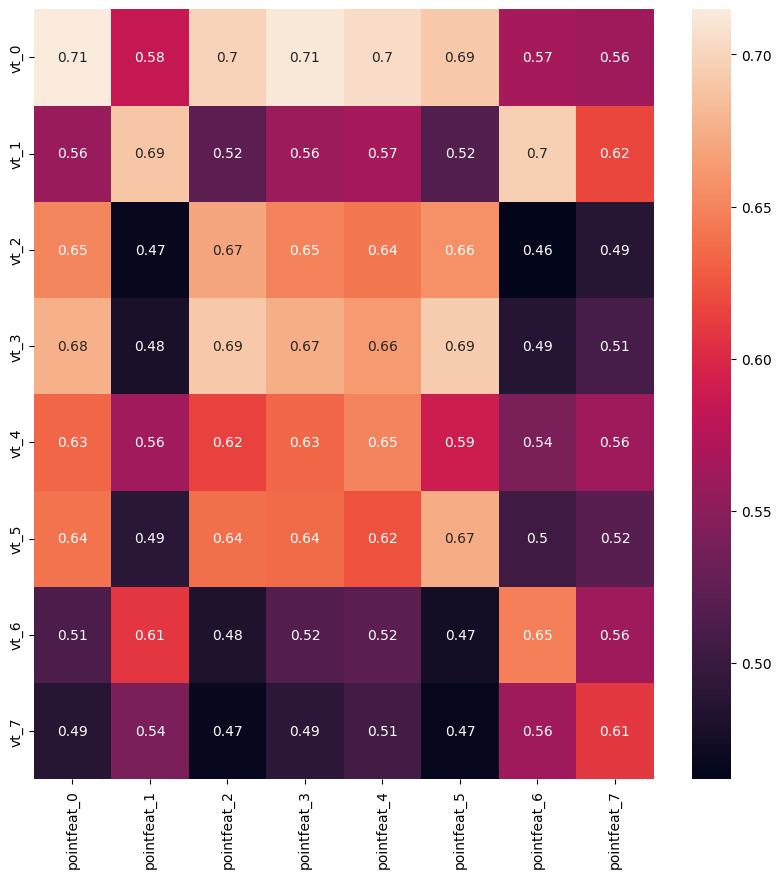

In [10]:
# Concatenate the tensors along the first dimension
visual_embeddings = torch.cat(image_tensors_list, dim=0)
text_embeddings = torch.cat(text_tensors_list, dim=0)
point_feat = torch.cat(no_train_feat_list, dim=0)
n = point_feat.shape[0]

# Compute cosine similarity between each pair of embeddings
similarities1 = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        similarities1[i, j] = np.dot((visual_embeddings[i].detach().numpy()+text_embeddings[i].detach().numpy())/2, point_feat[j].detach().numpy()) / \
            (np.linalg.norm(visual_embeddings[i].detach().numpy()) * np.linalg.norm(point_feat[j].detach().numpy()))

# Plot the resulting heatmap
df = pd.DataFrame(similarities1, columns=['pointfeat_' + str(i) for i in range(n)], index=['vt_' + str(i) for i in range(n)])
fig, ax = plt.subplots(figsize=(10,10))  
sns.heatmap(df, annot=True, ax=ax)
plt.show()